In [0]:
%pip install imbalanced-learn
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC, SVR
from xgboost import XGBClassifier

# Leitura do Dataset

In [0]:
list_cols_to_drop = [
    # De certa forma duplicadas com outras cols
    "RA"
    ,"Nome_Anonimizado"
    ,"Data_de_Nasc"
    ,"Fase_ideal"
    ,"IAN"
    # Categoricas nao tratadas
    ,"Turma"
    ,"Escola"
    ,"Instituicao_de_ensino"
]

df_pm = (
    spark.table("pos_fiap.datathon.passos_magicos")
    .drop(*list_cols_to_drop)
)

df_pm.limit(5).display()

Fase,Idade,Genero,Ano_ingresso,Pedra_20,Pedra_21,Pedra_22,INDE_22,Cg,Cf,Ct,No_Av,Avaliador1,Rec_Av1,Avaliador2,Rec_Av2,Avaliador3,Rec_Av3,Avaliador4,Rec_Av4,IAA,IEG,IPS,Rec_Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu_PV,IPV,Defasagem,Destaque_IEG,Destaque_IDA,Destaque_IPV,Ano,INDE_23,Pedra_23,IPP,INDE_24,Pedra_24,Avaliador5,Avaliador6,Ativo_Inativo,ID,INDE,Pedra,ian_defasagem
ALFA,8,Feminino,2023,null,null,null,null,null,null,null,2,Avaliador-11,null,Avaliador-2,null,null,null,null,null,9.5000,10.0000,8.1300,null,9.6000,9.8000,9.4000,null,null,null,8.9200,0,null,null,null,2023-01-01,9.3110,Topázio,8.4375,null,null,null,null,null,861,9.3110,Topázio,Em fase
ALFA,9,Masculino,2023,null,null,null,null,null,null,null,2,Avaliador-11,null,Avaliador-2,null,null,null,null,null,8.5000,9.1000,8.1400,null,8.9000,8.5000,9.2000,null,null,null,8.5850,-1,null,null,null,2023-01-01,8.2212,Topázio,7.5000,null,null,null,null,null,862,8.2212,Topázio,Moderada
ALFA,7,Masculino,2023,null,null,null,null,null,null,null,2,Avaliador-11,null,Avaliador-2,null,null,null,null,null,0.0000,7.6000,3.1400,null,6.3000,7.0000,5.5000,null,null,null,6.2600,0,null,null,null,2023-01-01,5.9298,Quartzo,5.9375,null,null,null,null,null,863,5.9298,Quartzo,Em fase
ALFA,8,Feminino,2023,null,null,null,null,null,null,null,2,Avaliador-11,null,Avaliador-2,null,null,null,null,null,0.0000,7.6000,8.1400,null,6.3000,7.0000,5.5000,null,null,null,8.5000,0,null,null,null,2023-01-01,7.0340,Ametista,7.5000,null,null,null,null,null,864,7.0340,Ametista,Em fase
ALFA,8,Masculino,2023,null,null,null,null,null,null,null,2,Avaliador-11,null,Avaliador-2,null,null,null,null,null,8.5000,8.7000,7.5200,null,7.4000,7.3000,7.5000,null,null,null,7.9150,0,null,null,null,2023-01-01,8.1552,Topázio,7.5000,null,null,null,null,null,865,8.1552,Topázio,Em fase


# Perguntas

## Perguntas para ser respondidas na análise

1. ~~Adequação do nível (IAN)~~\
~~Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui aolongo do ano?\
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)~~
2. ~~Desempenho acadêmico (IDA)~~\
~~O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?~~
3. ~~Engajamento nas atividades (IEG)~~\
~~O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?~~
4. ~~Autoavaliação (IAA)~~\
~~As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?~~
5. ~~Aspectos psicossociais (IPS)~~\
~~Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?~~
6. ~~Aspectos psicopedagógicos (IPP)~~\
~~As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?~~
7. ~~Ponto de virada (IPV)~~\
~~Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?~~
8. ~~Multidimensionalidade dos indicadores~~\
~~Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?~~
---
9. Previsão de risco com Machine Learning\
Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.
---
10. ~~Efetividade do programa~~\
~~Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?~~
11. ~~Insights e criatividade~~\
~~Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.~~

## 9. Previsão de risco com Machine Learning
Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

# Análise Exploratória

In [0]:
print((df_pm.count(), len(df_pm.columns)))

(3030, 48)


In [0]:
df_pm.select([count(when(col(c).isNull(), c)).alias(c) for c in df_pm.columns]).display()

Fase,Idade,Genero,Ano_ingresso,Pedra_20,Pedra_21,Pedra_22,INDE_22,Cg,Cf,Ct,No_Av,Avaliador1,Rec_Av1,Avaliador2,Rec_Av2,Avaliador3,Rec_Av3,Avaliador4,Rec_Av4,IAA,IEG,IPS,Rec_Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu_PV,IPV,Defasagem,Destaque_IEG,Destaque_IDA,Destaque_IPV,Ano,INDE_23,Pedra_23,IPP,INDE_24,Pedra_24,Avaliador5,Avaliador6,Ativo_Inativo,ID,INDE,Pedra,ian_defasagem
0,0,0,0,2276,1969,1098,1098,2170,2170,2170,76,203,2170,203,2170,996,2170,1979,2734,165,76,171,2170,178,184,185,1939,2170,2170,178,0,2170,2170,2170,0,1409,1409,1038,1976,1976,2882,3024,1874,0,185,185,0


In [0]:
df_pm.describe().display()

summary,Fase,Idade,Genero,Ano_ingresso,Pedra_20,Pedra_21,Pedra_22,INDE_22,Cg,Cf,Ct,No_Av,Avaliador1,Rec_Av1,Avaliador2,Rec_Av2,Avaliador3,Rec_Av3,Avaliador4,Rec_Av4,IAA,IEG,IPS,Rec_Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu_PV,IPV,Defasagem,Destaque_IEG,Destaque_IDA,Destaque_IPV,Ano,INDE_23,Pedra_23,IPP,INDE_24,Pedra_24,Avaliador5,Avaliador6,Ativo_Inativo,ID,INDE,Pedra,ian_defasagem
count,3030,3030,3030,3030,754,1061,1932,1932,860,860,860,2954,2827,860,2827,860,2034,860,1051,296,2865,2954,2859,860,2852,2846,2845,1091,860,860,2852,3030,860,860,860,3030,1621,1621,1992,1054,1054,148,6,1156,3030,2845,2845,3030
mean,2.9769496734537073,12.545214521452145,null,2021.563696369637,null,null,null,7.18769048,430.51627906976745,75.51976744186047,6.598837209302325,3.031821259309411,null,null,null,null,null,null,null,null,7.91947644,7.94556534,6.28720881,null,6.38085554,6.16170063,6.43072056,6.28941338,null,null,7.54523117,-0.642904290429043,null,null,null,null,7.39048007,null,7.55680793,7.39668634,null,null,null,null,721.6686468646865,7.26991550,null,null
stddev,2.161487461867905,3.3008750408308973,null,1.822170658791062,null,null,null,0.9543732915095342,248.43276103298834,52.31266998688333,3.9758582935271622,1.0636704308735419,null,null,null,null,null,null,null,null,2.6270664395375096,2.1518140549359948,1.7919777423142254,null,1.957297071165275,2.398380045616675,2.1389640077190535,2.7326357918976676,null,null,1.0850131397870937,0.8663822319013996,null,null,null,null,0.8817690796454363,null,0.9379653318134494,1.0139122089734751,null,null,null,null,438.5919588248376,0.9917657260963174,null,null
min,0,7,Feminino,2016,Ametista,Ametista,Ametista,3.0320,1,1,1,0,Avaliador-11,Alocado em Fase anterior,Avaliador-1,Mantido na Fase + Bolsa,Avaliador-1,Alocado em Fase anterior,Avaliador-1,Alocado em Fase anterior,0.0000,0.0000,2.5000,Não atendido,0.0000,0.0000,0.0000,0.0000,Não,Não,2.5000,-5,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios Passos Mágicos.,2022-01-01,3.7455,Ametista,2.5000,3.7895,Ametista,Avaliador-10,Avaliador-26,Cursando,1,3.0320,Ametista,Em fase
max,ALFA,27,Masculino,2024,Ágata,Ágata,Ágata,9.4420,862,192,18,6,Avaliador-7,Promovido de Fase + Bolsa,Avaliador-7,Promovido de Fase + Bolsa,Avaliador-9,Promovido de Fase + Bolsa,Avaliador-8,Promovido de Fase + Bolsa,10.0000,10.0000,10.0000,Sem limitações,10.0000,10.0000,10.0000,10.0000,Sim,Sim,10.0100,3,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.,2024-01-01,9.3712,Ágata,10.0000,9.5313,Ágata,Avaliador-7,Avaliador-26,Cursando,1661,9.5313,Ágata,Severa


In [0]:
df_pm.summary().display()

summary,Fase,Idade,Genero,Ano_ingresso,Pedra_20,Pedra_21,Pedra_22,INDE_22,Cg,Cf,Ct,No_Av,Avaliador1,Rec_Av1,Avaliador2,Rec_Av2,Avaliador3,Rec_Av3,Avaliador4,Rec_Av4,IAA,IEG,IPS,Rec_Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu_PV,IPV,Defasagem,Destaque_IEG,Destaque_IDA,Destaque_IPV,Ano,INDE_23,Pedra_23,IPP,INDE_24,Pedra_24,Avaliador5,Avaliador6,Ativo_Inativo,ID,INDE,Pedra,ian_defasagem
count,3030,3030,3030,3030,754,1061,1932,1932,860,860,860,2954,2827,860,2827,860,2034,860,1051,296,2865,2954,2859,860,2852,2846,2845,1091,860,860,2852,3030,860,860,860,3030,1621,1621,1992,1054,1054,148,6,1156,3030,2845,2845,3030
mean,2.9769496734537073,12.545214521452145,null,2021.563696369637,null,null,null,7.18769048,430.51627906976745,75.51976744186047,6.598837209302325,3.031821259309411,null,null,null,null,null,null,null,null,7.91947644,7.94556534,6.28720881,null,6.38085554,6.16170063,6.43072056,6.28941338,null,null,7.54523117,-0.642904290429043,null,null,null,null,7.39048007,null,7.55680793,7.39668634,null,null,null,null,721.6686468646865,7.26991550,null,null
stddev,2.161487461867905,3.3008750408308973,null,1.822170658791062,null,null,null,0.9543732915095342,248.43276103298834,52.31266998688333,3.9758582935271622,1.0636704308735419,null,null,null,null,null,null,null,null,2.6270664395375096,2.1518140549359948,1.7919777423142254,null,1.957297071165275,2.398380045616675,2.1389640077190535,2.7326357918976676,null,null,1.0850131397870937,0.8663822319013996,null,null,null,null,0.8817690796454363,null,0.9379653318134494,1.0139122089734751,null,null,null,null,438.5919588248376,0.9917657260963174,null,null
min,0,7,Feminino,2016,Ametista,Ametista,Ametista,3.0320,1,1,1,0,Avaliador-11,Alocado em Fase anterior,Avaliador-1,Mantido na Fase + Bolsa,Avaliador-1,Alocado em Fase anterior,Avaliador-1,Alocado em Fase anterior,0.0000,0.0000,2.5000,Não atendido,0.0000,0.0000,0.0000,0.0000,Não,Não,2.5000,-5,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios Passos Mágicos.,2022-01-01,3.7455,Ametista,2.5000,3.7895,Ametista,Avaliador-10,Avaliador-26,Cursando,1,3.0320,Ametista,Em fase
25%,1.0,10,null,2021,null,null,null,6.6710,215,30,3,2,null,null,null,null,null,null,null,null,7.9000,7.3000,5.0200,null,5.1000,4.8000,5.2000,4.5000,null,null,7.0000,-1,null,null,null,null,6.7841,null,7.1000,6.7669,null,null,null,null,364,6.6752,null,null
50%,3.0,12,null,2022,null,null,null,7.3060,430,67,6,3,null,null,null,null,null,null,null,null,8.8000,8.6000,7.5000,null,6.7000,6.3000,6.7000,6.7000,null,null,7.5875,-1,null,null,null,null,7.4543,null,7.5000,7.5398,null,null,null,null,689,7.3883,null,null
75%,4.0,15,null,2023,null,null,null,7.8620,645,118,9,4,null,null,null,null,null,null,null,null,9.5000,9.4000,7.5000,null,7.8000,8.0000,8.0000,8.5000,null,null,8.2550,0,null,null,null,null,8.0152,null,8.1250,8.1404,null,null,null,null,1057,7.9869,null,null
max,ALFA,27,Masculino,2024,Ágata,Ágata,Ágata,9.4420,862,192,18,6,Avaliador-7,Promovido de Fase + Bolsa,Avaliador-7,Promovido de Fase + Bolsa,Avaliador-9,Promovido de Fase + Bolsa,Avaliador-8,Promovido de Fase + Bolsa,10.0000,10.0000,10.0000,Sem limitações,10.0000,10.0000,10.0000,10.0000,Sim,Sim,10.0100,3,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.,2024-01-01,9.3712,Ágata,10.0000,9.5313,Ágata,Avaliador-7,Avaliador-26,Cursando,1661,9.5313,Ágata,Severa


# Feature Engineering


**Precaução**
- Se o aluno já está com defasagem em 2022 muito provavalmente ele também vai estar com defasagem em 2023

In [0]:
# Com window function lead
df = (
    df_pm
    .selectExpr(
        "*"
        ,'''lead(ano) over (partition by id order by ano) lead_ano'''
        ,'''lead(Defasagem) over (partition by id order by ano) lead_defasagem'''
        # ,'''lead(Ian_defasagem) over (partition by id order by ano) lead_class_defasagem'''
        # ,'''rank() over (partition by id order by ano) rank_ano'''
        ,'''rank() over (partition by id order by ano desc) rank_corte'''
    )
    # Criando a verdadeira coluna target do modelo
    # Lembrando de defasagem nao tem valores nulos
    .withColumn("teve_defasagem", when(col("lead_defasagem") >= col("Defasagem"), 0).otherwise(1))
    # Descartar ultimo ano de cada aluno por nao ter como validar
    .filter("rank_corte > 1")
    # Descartar saltos de 2022 para 2024 (apenas 4 linhas)
    .filter(add_months("lead_ano", -12) == col("ano"))
    .drop("lead_ano", "lead_defasagem", "rank_corte")
    .orderBy("id", "ano")
)

df.limit(5).display()

Fase,Idade,Genero,Ano_ingresso,Pedra_20,Pedra_21,Pedra_22,INDE_22,Cg,Cf,Ct,No_Av,Avaliador1,Rec_Av1,Avaliador2,Rec_Av2,Avaliador3,Rec_Av3,Avaliador4,Rec_Av4,IAA,IEG,IPS,Rec_Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu_PV,IPV,Defasagem,Destaque_IEG,Destaque_IDA,Destaque_IPV,Ano,INDE_23,Pedra_23,IPP,INDE_24,Pedra_24,Avaliador5,Avaliador6,Ativo_Inativo,ID,INDE,Pedra,ian_defasagem,teve_defasagem
7,19,Feminino,2016,Ametista,Ametista,Quartzo,5.7830,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3000,4.1000,5.6000,Requer avaliação,4.0000,2.7000,3.5000,6.0000,Sim,Não,7.2780,-1,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.,2022-01-01,null,null,null,null,null,null,null,null,1,5.7830,Quartzo,Moderada,0
8,20,Feminino,2016,Ametista,Ametista,Quartzo,5.7830,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,null,null,null,2023-01-01,null,null,null,null,null,null,null,null,1,null,null,Em fase,0
7,17,Feminino,2017,Ametista,Ametista,Ametista,7.0550,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8000,5.2000,6.3000,Sem limitações,6.8000,6.3000,4.5000,9.7000,Não,Não,6.7780,0,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.,2022-01-01,null,null,null,null,null,null,null,null,2,7.0550,Ametista,Em fase,0
8,18,Feminino,2017,Ametista,Ametista,Ametista,7.0550,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,null,null,null,2023-01-01,null,null,null,null,null,null,null,null,2,null,null,Em fase,0
7,17,Feminino,2016,Ametista,Ametista,Ametista,7.4270,344,6,2,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.9000,8.6000,5.6000,Requer avaliação,5.2000,7.0000,2.9000,5.7000,Não,Não,7.3890,0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.,2022-01-01,null,null,null,null,null,null,null,null,5,7.4270,Ametista,Em fase,0


Databricks visualization. Run in Databricks to view.

In [0]:
total_rows = df.count()

# Calcular percentual de preenchimento das colunas
dict_preenchimento_cols = {c: df.filter(col(c).isNotNull()).count() / total_rows for c in df.columns}

dict_preenchimento_cols

{'Fase': 1.0,
 'Idade': 1.0,
 'Genero': 1.0,
 'Ano_ingresso': 1.0,
 'Pedra_20': 0.3142857142857143,
 'Pedra_21': 0.43736263736263736,
 'Pedra_22': 0.7824175824175824,
 'INDE_22': 0.7824175824175824,
 'Cg': 0.43956043956043955,
 'Cf': 0.43956043956043955,
 'Ct': 0.43956043956043955,
 'No_Av': 0.9472527472527472,
 'Avaliador1': 0.9472527472527472,
 'Rec_Av1': 0.43956043956043955,
 'Avaliador2': 0.9472527472527472,
 'Rec_Av2': 0.43956043956043955,
 'Avaliador3': 0.6366300366300366,
 'Rec_Av3': 0.43956043956043955,
 'Avaliador4': 0.30622710622710625,
 'Rec_Av4': 0.13113553113553114,
 'IAA': 0.9567765567765568,
 'IEG': 0.9472527472527472,
 'IPS': 0.9545787545787546,
 'Rec_Psicologia': 0.43956043956043955,
 'IDA': 0.9472527472527472,
 'Mat': 0.9472527472527472,
 'Por': 0.9472527472527472,
 'Ing': 0.2996336996336996,
 'Indicado': 0.43956043956043955,
 'Atingiu_PV': 0.43956043956043955,
 'IPV': 0.9472527472527472,
 'Defasagem': 1.0,
 'Destaque_IEG': 0.43956043956043955,
 'Destaque_IDA': 0.4395

In [0]:
# Acima de 90% de preenchimento
list_cols_relevantes = [chave for chave, valor in dict_preenchimento_cols.items() if valor >= .9]

list_cols_relevantes

['Fase',
 'Idade',
 'Genero',
 'Ano_ingresso',
 'No_Av',
 'Avaliador1',
 'Avaliador2',
 'IAA',
 'IEG',
 'IPS',
 'IDA',
 'Mat',
 'Por',
 'IPV',
 'Defasagem',
 'Ano',
 'ID',
 'INDE',
 'Pedra',
 'ian_defasagem',
 'teve_defasagem']

In [0]:
# Descartar colunas irrelevantes
df = df.select(list_cols_relevantes)

df.limit(5).display()

Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,Mat,Por,IPV,Defasagem,Ano,ID,INDE,Pedra,ian_defasagem,teve_defasagem
7,19,Feminino,2016,4,Avaliador-5,Avaliador-27,8.3000,4.1000,5.6000,4.0000,2.7000,3.5000,7.2780,-1,2022-01-01,1,5.7830,Quartzo,Moderada,0
8,20,Feminino,2016,null,null,null,null,null,null,null,null,null,null,0,2023-01-01,1,null,null,Em fase,0
7,17,Feminino,2017,4,Avaliador-5,Avaliador-27,8.8000,5.2000,6.3000,6.8000,6.3000,4.5000,6.7780,0,2022-01-01,2,7.0550,Ametista,Em fase,0
8,18,Feminino,2017,null,null,null,null,null,null,null,null,null,null,0,2023-01-01,2,null,null,Em fase,0
7,17,Feminino,2016,4,Avaliador-5,Avaliador-27,7.9000,8.6000,5.6000,5.2000,7.0000,2.9000,7.3890,0,2022-01-01,5,7.4270,Ametista,Em fase,0


In [0]:
dict_cols_counts = df.select([countDistinct(c).alias(c) for c in df.columns]).collect()[0].asDict()

# Acima de 12 valores unicos, contiua, senao categorica
list_continuas = [col for col, count in dict_cols_counts.items() if count > 12]
list_categoricas = [col for col, count in dict_cols_counts.items() if count <= 12]

In [0]:
list_continuas

['Idade', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'IPV', 'ID', 'INDE']

In [0]:
list_categoricas

['Fase',
 'Genero',
 'Ano_ingresso',
 'No_Av',
 'Avaliador1',
 'Avaliador2',
 'Defasagem',
 'Ano',
 'Pedra',
 'ian_defasagem',
 'teve_defasagem']

In [0]:
dict_mediana = {c: df.approxQuantile(c, [0.5], 0.001)[0] for c in list_continuas}

dict_mediana

{'Idade': 12.0,
 'IAA': 8.8,
 'IEG': 8.9,
 'IPS': 6.89,
 'IDA': 6.8,
 'Mat': 6.5,
 'Por': 7.0,
 'IPV': 7.833,
 'ID': 588.0,
 'INDE': 7.4543}

In [0]:
dict_moda = {c: df.groupBy(c).count().orderBy(col("count").desc()).first()[0] for c in list_categoricas}

dict_moda

{'Fase': '1',
 'Genero': 'Feminino',
 'Ano_ingresso': 2022,
 'No_Av': 3,
 'Avaliador1': 'Avaliador-15',
 'Avaliador2': 'Avaliador-3',
 'Defasagem': -1,
 'Ano': '2023-01-01',
 'Pedra': 'Ametista',
 'ian_defasagem': 'Moderada',
 'teve_defasagem': 0}

In [0]:
# Unificar dicionarios
dict_fill = dict_mediana | dict_moda

# Tratar nulos com medianas para as continuas e moda para as categoricas
df = df.fillna(dict_fill)

df.limit(5).display()

Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,Mat,Por,IPV,Defasagem,Ano,ID,INDE,Pedra,ian_defasagem,teve_defasagem
7,19,Feminino,2016,4,Avaliador-5,Avaliador-27,8.3000,4.1000,5.6000,4.0000,2.7000,3.5000,7.2780,-1,2022-01-01,1,5.7830,Quartzo,Moderada,0
8,20,Feminino,2016,3,Avaliador-15,Avaliador-3,8.8000,8.9000,6.8900,6.8000,6.5000,7.0000,7.8330,0,2023-01-01,1,7.4543,Ametista,Em fase,0
7,17,Feminino,2017,4,Avaliador-5,Avaliador-27,8.8000,5.2000,6.3000,6.8000,6.3000,4.5000,6.7780,0,2022-01-01,2,7.0550,Ametista,Em fase,0
8,18,Feminino,2017,3,Avaliador-15,Avaliador-3,8.8000,8.9000,6.8900,6.8000,6.5000,7.0000,7.8330,0,2023-01-01,2,7.4543,Ametista,Em fase,0
7,17,Feminino,2016,4,Avaliador-5,Avaliador-27,7.9000,8.6000,5.6000,5.2000,7.0000,2.9000,7.3890,0,2022-01-01,5,7.4270,Ametista,Em fase,0


In [0]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).display()

Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,Mat,Por,IPV,Defasagem,Ano,ID,INDE,Pedra,ian_defasagem,teve_defasagem
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
df.groupBy("ano", "teve_defasagem").count().display()

ano,teve_defasagem,count
2022-01-01,0,496
2023-01-01,0,633
2023-01-01,1,132
2022-01-01,1,104


Databricks visualization. Run in Databricks to view.

In [0]:
# Pandas converte decimais para string...vou tratar por aqui

# Identificar colunas Decimal
decimal_columns = [field.name for field in df.schema.fields if isinstance(field.dataType, DecimalType)]

# Converter todas para double
for col_name in decimal_columns:
    df = df.withColumn(col_name, col(col_name).cast(DoubleType()))

## Pandas

In [0]:
pandas_df = df.toPandas()

pandas_df

,Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,Mat,Por,IPV,Defasagem,Ano,ID,INDE,Pedra,ian_defasagem,teve_defasagem
0,7,19,Feminino,2016,4,Avaliador-5,Avaliador-27,8.3,4.1,5.60,4.0,2.7,3.5,7.278,-1,2022-01-01,1,5.7830,Quartzo,Moderada,0
1,8,20,Feminino,2016,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,6.5,7.0,7.833,0,2023-01-01,1,7.4543,Ametista,Em fase,0
2,7,17,Feminino,2017,4,Avaliador-5,Avaliador-27,8.8,5.2,6.30,6.8,6.3,4.5,6.778,0,2022-01-01,2,7.0550,Ametista,Em fase,0
3,8,18,Feminino,2017,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,6.5,7.0,7.833,0,2023-01-01,2,7.4543,Ametista,Em fase,0
4,7,17,Feminino,2016,4,Avaliador-5,Avaliador-27,7.9,8.6,5.60,5.2,7.0,2.9,7.389,0,2022-01-01,5,7.4270,Ametista,Em fase,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1360,8,19,Feminino,2021,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,6.5,7.0,7.833,0,2023-01-01,1270,7.4543,Ametista,Em fase,0
1361,8,18,Feminino,2021,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,6.5,7.0,7.833,0,2023-01-01,1271,7.4543,Ametista,Em fase,0
1362,8,19,Feminino,2021,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,6.5,7.0,7.833,0,2023-01-01,1272,7.4543,Ametista,Em fase,0
1363,8,17,Feminino,2023,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,6.5,7.0,7.833,1,2023-01-01,1273,7.4543,Ametista,Em fase,1


In [0]:
pandas_df.shape

(1365, 21)

<Axes: xlabel='teve_defasagem', ylabel='count'>

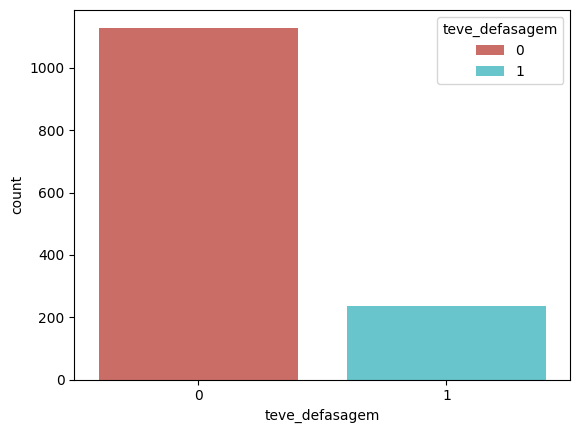

In [0]:
sns.countplot(x='teve_defasagem', hue='teve_defasagem', data=pandas_df, palette='hls')

In [0]:
# Correlacao das variaveis independentes com a target

matriz_correlacao = pandas_df.corr(numeric_only=True).round(2)

correlacao_resultado = matriz_correlacao['teve_defasagem']

display(correlacao_resultado)

Idade            -0.24
Ano_ingresso      0.17
No_Av            -0.15
IAA              -0.01
IEG              -0.03
IPS               0.05
IDA              -0.08
Mat              -0.06
Por              -0.09
IPV              -0.15
Defasagem         0.31
ID                0.11
INDE              0.00
teve_defasagem    1.00
Name: teve_defasagem, dtype: float64

## Pré Processamento

### Feature Selection

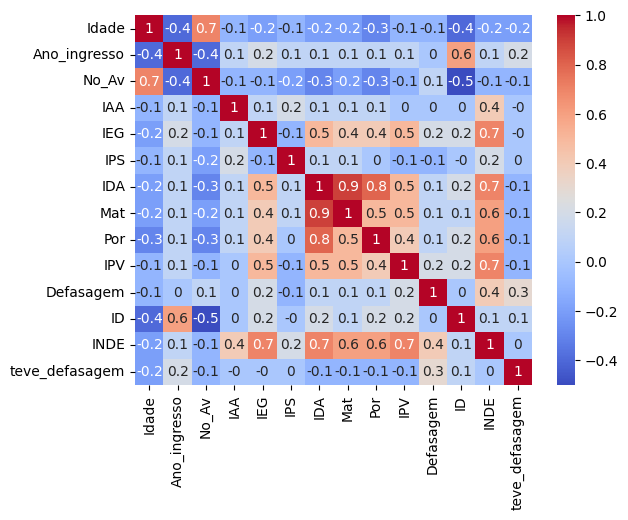

In [0]:
matriz_correlcao_full = pandas_df.corr(numeric_only=True).round(1)

# Visualizando com Seaborn
sns.heatmap(matriz_correlcao_full, annot=True, cmap='coolwarm')
plt.show()

In [0]:
# Alta correlacao >= .8 entre IDA e Mat, e IDA e Por, como era de se esperar dado que elas compoem a nota de IDA
# Descartando Mat e Por

pandas_df = pandas_df.drop(columns=['Mat', 'Por'])

### Separação Treino / Teste

In [0]:
X = pandas_df.drop(columns=['teve_defasagem'])

X

,Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,IPV,Defasagem,Ano,ID,INDE,Pedra,ian_defasagem
0,7,19,Feminino,2016,4,Avaliador-5,Avaliador-27,8.3,4.1,5.60,4.0,7.278,-1,2022-01-01,1,5.7830,Quartzo,Moderada
1,8,20,Feminino,2016,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,7.833,0,2023-01-01,1,7.4543,Ametista,Em fase
2,7,17,Feminino,2017,4,Avaliador-5,Avaliador-27,8.8,5.2,6.30,6.8,6.778,0,2022-01-01,2,7.0550,Ametista,Em fase
3,8,18,Feminino,2017,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,7.833,0,2023-01-01,2,7.4543,Ametista,Em fase
4,7,17,Feminino,2016,4,Avaliador-5,Avaliador-27,7.9,8.6,5.60,5.2,7.389,0,2022-01-01,5,7.4270,Ametista,Em fase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1360,8,19,Feminino,2021,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,7.833,0,2023-01-01,1270,7.4543,Ametista,Em fase
1361,8,18,Feminino,2021,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,7.833,0,2023-01-01,1271,7.4543,Ametista,Em fase
1362,8,19,Feminino,2021,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,7.833,0,2023-01-01,1272,7.4543,Ametista,Em fase
1363,8,17,Feminino,2023,3,Avaliador-15,Avaliador-3,8.8,8.9,6.89,6.8,7.833,1,2023-01-01,1273,7.4543,Ametista,Em fase


In [0]:
y = pandas_df[['teve_defasagem']]

y

,teve_defasagem
0,0
1,0
2,0
3,0
4,0
...,...
1360,0
1361,0
1362,0
1363,1


In [0]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=37)

groups = pandas_df['ID']

# Forcando cada aluno a participar de apenas um dos grupos e assim poder generalizar
gkf = GroupKFold(n_splits=5)

for train_index, test_index in gkf.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Dropar ID para nao enviesar o modelo
X_train = X_train.drop(columns='ID')
X_test = X_test.drop(columns='ID')

In [0]:
X_train.shape

(1092, 17)

In [0]:
X_test.shape

(273, 17)

### Feature Encoding

In [0]:
colunas_categoricas = pandas_df.select_dtypes(include=['object']).columns.tolist()

colunas_categoricas

['Fase', 'Genero', 'Avaliador1', 'Avaliador2', 'Ano', 'Pedra', 'ian_defasagem']

In [0]:
encoder = TargetEncoder()

X_train[colunas_categoricas] = encoder.fit_transform(X_train[colunas_categoricas], y_train)

X_train

/databricks/python/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,IPV,Defasagem,Ano,INDE,Pedra,ian_defasagem
2,0.452799,17,0.165972,2017,4,0.107551,0.135590,8.8,5.2,6.30,6.8,6.778,0,0.165404,7.0550,0.156443,0.325481
3,0.000000,18,0.174374,2017,3,0.068310,0.279758,8.8,8.9,6.89,6.8,7.833,0,0.174004,7.4543,0.155857,0.307796
4,0.452799,17,0.165972,2016,4,0.107551,0.135590,7.9,8.6,5.60,5.2,7.389,0,0.165404,7.4270,0.156443,0.325481
5,0.270535,18,0.174374,2021,4,0.093038,0.146351,7.9,4.5,7.50,3.3,7.222,-1,0.179136,5.8480,0.193253,0.084909
6,0.023811,19,0.177727,2021,3,0.083142,0.236951,8.8,8.9,6.89,6.8,7.833,0,0.168714,7.4543,0.164378,0.311238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,0.023811,22,0.177727,2021,3,0.083142,0.236951,8.8,8.9,6.89,6.8,7.833,0,0.168714,7.4543,0.164378,0.311238
1358,0.031195,19,0.190211,2021,3,0.077211,0.258994,8.8,8.9,6.89,6.8,7.833,0,0.186838,7.4543,0.156443,0.325481
1359,0.031195,18,0.165972,2021,3,0.077211,0.258994,8.8,8.9,6.89,6.8,7.833,0,0.186838,7.4543,0.156443,0.325481
1360,0.031195,19,0.165972,2021,3,0.077211,0.258994,8.8,8.9,6.89,6.8,7.833,0,0.186838,7.4543,0.156443,0.325481


In [0]:
X_test[colunas_categoricas] = encoder.transform(X_test[colunas_categoricas])

X_test

,Fase,Idade,Genero,Ano_ingresso,No_Av,Avaliador1,Avaliador2,IAA,IEG,IPS,IDA,IPV,Defasagem,Ano,INDE,Pedra,ian_defasagem
0,0.322717,19,0.171196,2016,4,0.110622,0.148076,8.3,4.1,5.60,4.0,7.278,-1,0.172278,5.7830,0.184110,0.082356
1,0.021287,20,0.171196,2016,3,0.079510,0.257937,8.8,8.9,6.89,6.8,7.833,0,0.180189,7.4543,0.153739,0.312886
7,0.322717,18,0.183254,2017,4,0.110622,0.148076,0.0,8.4,7.50,7.6,7.667,-1,0.172278,6.8180,0.195997,0.082356
8,0.021287,19,0.183254,2017,3,0.079510,0.257937,8.8,8.9,6.89,6.8,7.833,0,0.180189,7.4543,0.153739,0.312886
17,0.322717,19,0.171196,2022,4,0.140614,0.148076,7.9,9.5,7.50,8.0,7.000,-1,0.172278,7.6650,0.153739,0.082356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351,0.021287,19,0.171196,2021,3,0.079510,0.257937,8.8,8.9,6.89,6.8,7.833,0,0.180189,7.4543,0.153739,0.312886
1356,0.021287,19,0.171196,2021,3,0.079510,0.257937,8.8,8.9,6.89,6.8,7.833,0,0.180189,7.4543,0.153739,0.312886
1361,0.021287,18,0.171196,2021,3,0.079510,0.257937,8.8,8.9,6.89,6.8,7.833,0,0.180189,7.4543,0.153739,0.312886
1363,0.021287,17,0.171196,2023,3,0.079510,0.257937,8.8,8.9,6.89,6.8,7.833,1,0.180189,7.4543,0.153739,0.312886


In [0]:
set(X_train['Fase'])

{0.0,
 0.023810639158399788,
 0.024995078311433237,
 0.02854290461461366,
 0.03119504236530585,
 0.04593799514659114,
 0.0551420119805305,
 0.06575358208281841,
 0.06884285831986374,
 0.07257926580519143,
 0.10872099523897648,
 0.11855902159964442,
 0.12215910363173658,
 0.13117200616671476,
 0.13378529398346592,
 0.1374293821914638,
 0.13789294088106172,
 0.1431136680629512,
 0.1493364884304938,
 0.15258112112511169,
 0.1560174149731471,
 0.1619278371070026,
 0.16299107619803888,
 0.16672284796538894,
 0.17115041832965996,
 0.21483395672667188,
 0.24125911787337184,
 0.26149797557857585,
 0.2619904499902163,
 0.2705345839554873,
 0.2924912757762015,
 0.2931844719821492,
 0.2948340642649095,
 0.3056712592305716,
 0.3056755608026815,
 0.30728944713572004,
 0.319136095486001,
 0.32116335123120693,
 0.32322731845118885,
 0.36263330287333323,
 0.3633992910835553,
 0.3641883251904301,
 0.3722050302858499,
 0.45279906298284306}

### Oversample

In [0]:
smote = SMOTE(random_state=37)

X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)

In [0]:
X_train_oversampled.shape

(1798, 17)

<Axes: xlabel='teve_defasagem', ylabel='count'>

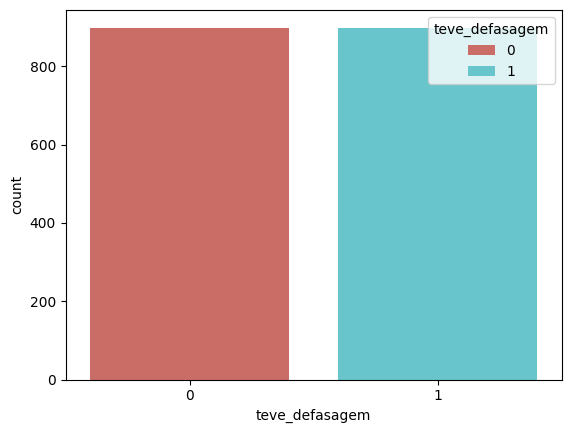

In [0]:
sns.countplot(x='teve_defasagem', hue='teve_defasagem', data=y_train_oversampled, palette='hls')

### Scaler

In [0]:
scaler = StandardScaler()

# Fit e Transform nos dados de treino
X_train_over_scaled = scaler.fit_transform(X_train_oversampled)

X_train_over_scaled

array([[ 2.39648877,  1.83419243, -1.40353798, ..., -0.38253072,
        -0.84705356,  1.06277631],
       [-1.89475705,  2.15534132, -0.29294915, ...,  0.08284679,
        -0.8718967 ,  0.90542946],
       [ 2.39648877,  1.83419243, -1.40353798, ...,  0.05102909,
        -0.84705356,  1.06277631],
       ...,
       [ 1.29786203,  0.54959686, -0.14968462, ..., -0.58297753,
        -0.34678991,  1.03549728],
       [ 1.33986799, -0.73499872, -1.40353798, ..., -0.38612583,
        -0.49433774, -1.20826515],
       [-0.72594999,  1.19189464, -0.33864604, ..., -1.04324119,
         0.87295763, -1.07753948]])

In [0]:
# Transform nos dados de teste
X_test_scaled = scaler.transform(X_test)

X_test_scaled

array([[ 1.16367979,  2.47649022, -0.71301436, ..., -1.86502557,
         0.32575159, -1.1004295 ],
       [-1.6930133 ,  2.79763911, -0.71301436, ...,  0.08284679,
        -0.96166119,  0.95071502],
       [ 1.16367979,  2.15534132,  0.88082261, ..., -0.65875028,
         0.82960188, -1.1004295 ],
       ...,
       [-1.6930133 ,  2.15534132, -0.71301436, ...,  0.08284679,
        -0.96166119,  0.95071502],
       [-1.6930133 ,  1.83419243, -0.71301436, ...,  0.08284679,
        -0.96166119,  0.95071502],
       [-1.6930133 ,  2.15534132, -0.71301436, ...,  0.08284679,
        -0.96166119,  0.95071502]])

# Modelagem Preditiva

In [0]:
dict_modelos = {
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=5)
    ,"DecisionTreeClassifier": DecisionTreeClassifier(random_state=37, max_depth=2, criterion='entropy')
    ,"LogisticRegression": LogisticRegression(max_iter=100)
    ,"GaussianNB": GaussianNB()
    ,"RandomForestClassifier": RandomForestClassifier(random_state=37, max_depth=2, n_estimators=5)
    ,"DecisionTreeClassifier": DecisionTreeClassifier()
    ,"SVM": SVC(probability=True)
    ,"XGBClassifier": XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, objective='binary:logistic')
}

list_predictions = []

for nome, modelo in dict_modelos.items():
    # Treinar
    modelo.fit(X_train_over_scaled, y_train_oversampled)

    # Predizer
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    # Gerar relatorio focado na probabilidade da classe positiva
    relatorio = classification_report(y_test, y_pred, output_dict=True)
    auc_score = roc_auc_score(y_test, y_prob)

    # Estruturar metricas
    metricas_modelo = {
        "Modelo": nome
        ,"Acurácia": relatorio["accuracy"]
        ,"Precisão": relatorio["1"]["precision"]
        ,"Recall": relatorio["1"]["recall"]
        ,"F1-Score": relatorio["1"]["f1-score"]
        ,"ROC AUC": auc_score
    }

    # Add na lista
    list_predictions.append(metricas_modelo)

df_resultados = pd.DataFrame(list_predictions)
df_resultados = df_resultados.round(2).sort_values(by=["ROC AUC", "F1-Score", "Recall", "Precisão"], ascending=[False, False, False, False]).reset_index(drop=True)

/databricks/python/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/databricks/python_shell/lib/dbruntime/MLWorkloadsInstrumentation/_sklearn.py:29: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape 

# Análise de Modelos

In [0]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC AUC
0,LogisticRegression,0.84,0.49,0.79,0.61,0.90
1,SVM,0.85,0.52,0.77,0.62,0.89
2,XGBClassifier,0.77,0.39,0.86,0.54,0.88
3,KNeighborsClassifier,0.76,0.37,0.70,0.48,0.84
4,GaussianNB,0.83,0.46,0.60,0.53,0.80
5,RandomForestClassifier,0.80,0.41,0.56,0.47,0.78
6,DecisionTreeClassifier,0.82,0.45,0.67,0.54,0.76
